# Zadanie 5: programowanie genetyczne i regresja symboliczna

Termin realizacji: 18 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład `pysr_demo.ipynb` tak, aby uczył się funkcji $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$ której dziedziną jest $\mathbb{R}^6$. Uczenie ma się odbywać w oparciu o 200 wylosowanych z dziedziny próbek (między -5 a 5).
2. Zanotuj wzory trzech rozwiązań o najwyższej wartości `score` oraz rozwiązanie `best` dla następujących zestawów ustawień:
   1. `binary_operators=["+", "*"], unary_operators=["cos", "exp", "sin"], maxsize=20`,
   2. `binary_operators=["+", "*", "-", "^"], unary_operators=["cos", "exp", "sin", "log"], maxsize=30`, (dodaj ograniczenie dla argumentów operatora "^": [https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators](https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators).
   3. `binary_operators=["+", "*", "-", "^"], unary_operators=["exp", "sin"], maxsize=15`.
3. Powtórz eksperymenty z zadania na 3.0 po dodaniu szumu do próbek z funkcji $f$ (rozkład normalny o średniej 0 i odchyleniu standardowym 0.5)

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do porównania dopasowanie oparte o próbki losowane w szerszym zakresie (między -15 a 15) oraz wyższy poziom szumu (odchylenie standardowe równe 2 oraz 5).

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień funkcję $f$ na $f(x) = 2.2\sin(x_0 + 2x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$ gdzie $p(i)$ oznacza $i$-tą liczbę pierwszą. Uwzględnij `p` jako dodatkowy operator unarny analogicznie do przykładu "Julia packages and types" z notatnika `pysr_demo.ipynb`. Powtórz eksperymenty opisane w zadaniach na 3.0 i 4.0.


In [2]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Zadanie na 3.0

In [3]:
np.random.seed(0)
X = np.random.randn(200, 6) * 5
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

In [4]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=1000,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Model 1:


[ Info: Started!



Expressions evaluated per second: 6.450e+05
Progress: 3669 / 31000 total iterations (11.835%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.529
4           7.770e+02  1.668e-03  y = sin(x₁) + -23.568
5           8.702e+00  4.492e+00  y = (x₅ * -1.0571) * x₅
7           2.381e+00  6.481e-01  y = ((x₅ * -1.0037) * x₅) + -3.1152
9           2.380e+00  1.819e-04  y = (((x₅ * -1.0038) + 0.0065523) * x₅) + -3.1122
11          2.336e+00  9.312e-03  y = (-3.8865 + (x₅ * (-1.0038 * x₅))) + cos(cos(x₁))
13          2.297e+00  8.332e-03  y = cos(sin(x₄ + -0.81984)) + (((x₅ * -1.0038) * x₅) + -3....
                                      8864)
14          7.083e-01  1.177e+00  y = ((x₅ * x₅) * -1.002) + (sin(x₁ + (x₀ + x₁)) + -3.0628)
16          4.621e-12  1.28

[ Info: Final population:
[ Info: Results saved to:


...

  - outputs/20260504_191753_IJo8ly/hall_of_fame.csv

Expressions evaluated per second: 6.190e+05
Progress: 3670 / 31000 total iterations (11.839%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.532
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1902 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = (x₅ * (x₅ * -1.0037)) + -3.1152
9           2.351e+00  6.244e-03  y = (-3.9022 - (x₅ * x₅)) + cos(cos(x₁))
10          2.140e+00  9.423e-02  y = (sin(13.57 ^ x₅) + -3.3981) - (x₅ * x₅)
12          2.108e+00  7.572e-03  y = (-3.4132 - (x₅ * x₅)) + sin((13.57 ^ x₅) + 0.24459)
14          2.082e+00  6.077e-03  y = (sin((17.971 ^ x₅) - (x₅ * x₅)) + -3.2881) - (x₅ * x₅)
15          2.073e+00  4.349e-03  y = (sin(

[ Info: Started!



Expressions evaluated per second: 6.800e+05
Progress: 15109 / 31000 total iterations (48.739%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.532
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1902 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = -3.1155 - (x₅ * (x₅ * 1.0037))
9           2.323e+00  1.221e-02  y = -2.861 - (((x₅ * x₅) ^ 0.9856) * 1.0725)
10          2.129e+00  8.730e-02  y = sin(13.57 ^ x₅) + (-3.2899 - (x₅ * x₅))
12          7.108e-01  5.485e-01  y = (sin(x₀ - (x₁ * -2.0044)) - (x₅ * x₅)) + -3.1046
14          4.621e-12  1.288e+01  y = ((sin(x₀ + (x₁ + x₁)) * 2.2) + -3) - (x₅ * x₅)
───────────────────────────────────────────────────────────────────────────────────────────────────
══

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.990e+05
Progress: 28145 / 31000 total iterations (90.790%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.532
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1902 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = -3.1155 - (x₅ * (x₅ * 1.0037))
9           2.323e+00  1.221e-02  y = -2.861 - (((x₅ * x₅) ^ 0.9856) * 1.0725)
10          2.117e+00  9.310e-02  y = (sin(13.581 ^ x₅) + -3.2329) - (x₅ * x₅)
12          7.108e-01  5.456e-01  y = (sin(x₀ - (x₁ * -2.0044)) - (x₅ * x₅)) + -3.1046
14          4.306e-12  1.291e+01  y = ((sin((x₁ + x₁) + x₀) * 2.2) + -3) - (x₅ * x₅)
───────────────────────────────────────────────────────────────────────────────────────────────────
═

In [8]:
for model in models:
    print(model.sympy())

x5*(-1.0)*x5 + sin(x0 + x1 + x1)*2.1999998 - 3.000001
-x5*x5 + sin(x0 + x1 + x1)*2.1999998 - 3.000001
-x5*x5 + sin(x0 + x1 + x1)*2.1999996 - 3.000001


In [9]:
np.random.seed(0)

X = np.random.randn(200, 6) * 5

y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 0.5

noise = np.random.normal(0, noise_level, size=y_true.shape)

y_noisy = y_true + noise

Text(0, 0.5, '$y$')

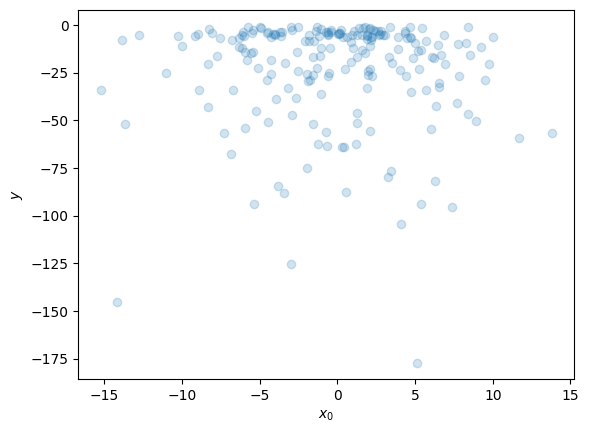

In [11]:
plt.scatter(X[:, 1], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

In [12]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=1000,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.120e+05
Progress: 3845 / 31000 total iterations (12.403%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.531
4           7.770e+02  1.668e-03  y = sin(x₁) + -23.567
5           8.702e+00  4.492e+00  y = x₅ * (x₅ * -1.0571)
7           2.381e+00  6.481e-01  y = ((x₅ * -1.0037) * x₅) + -3.1152
9           2.380e+00  1.820e-04  y = ((x₅ + -0.0065723) * (x₅ * -1.0038)) + -3.1119
11          2.336e+00  9.323e-03  y = cos(cos(x₁)) + (((x₅ * -1.0037) * x₅) + -3.8945)
12          2.289e+00  2.015e-02  y = (x₅ * (((sin(x₂) * 0.012297) + -1.0062) * x₅)) + -3.09...
                                      06
13          2.213e+00  3.378e-02  y = (x₅ * (x₅ * -1.0042)) + (sin(exp(x₃ * -4.2402)) + -3.1...
                          

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.380e+05
Progress: 1853 / 31000 total iterations (5.977%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.534
4           7.766e+02  1.837e-03  y = -23.562 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1903 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = -3.1152 - ((x₅ * 1.0037) * x₅)
9           2.347e+00  7.055e-03  y = -2.4301 - (cos(sin(x₁)) + (x₅ * x₅))
10          2.329e+00  7.901e-03  y = (sin(x₂) * 0.35296) - ((x₅ * x₅) - -3.2262)
11          2.311e+00  7.738e-03  y = -2.4325 - (cos(cos(x₄ - 0.81953)) + (x₅ * x₅))
12          2.288e+00  1.006e-02  y = (sin(x₄ + x₄) * 0.35296) - ((x₅ * x₅) - -3.2262)
13          2.287e+00  5.023e-04  y = ((cos(exp(x₃ - -0.83052)) * -0.37182) - (x₅ * x₅)) - 3...
        

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.490e+05
Progress: 4241 / 31000 total iterations (13.681%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.531
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1903 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = ((x₅ * -1.0037) * x₅) - 3.1152
9           2.346e+00  7.225e-03  y = (cos(cos(x₁)) - (x₅ * x₅)) + -3.97
10          2.262e+00  3.660e-02  y = -3.2416 + (sin(0.24211 ^ x₃) - (x₅ * x₅))
11          2.248e+00  6.085e-03  y = sin(sin(28.16 ^ x₃)) - ((x₅ * x₅) + 3.2257)
12          7.114e-01  1.151e+00  y = (sin((x₁ + x₀) + x₁) + -3.1038) - (x₅ * x₅)
14          4.621e-12  1.288e+01  y = ((sin((x₁ + x₁) + x₀) * 2.2) + -3) - (x₅ * x₅)
──────────────────────────────

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.790e+05
Progress: 27954 / 31000 total iterations (90.174%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.531
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1903 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = ((x₅ * -1.0037) * x₅) - 3.1152
9           2.346e+00  7.225e-03  y = (cos(cos(x₁)) - (x₅ * x₅)) + -3.97
10          2.138e+00  9.309e-02  y = sin(6.3447 ^ x₃) + (-3.2807 - (x₅ * x₅))
11          2.138e+00  1.241e-04  y = sin(sin(6.3447 ^ x₃)) + (-3.2807 - (x₅ * x₅))
12          7.108e-01  1.101e+00  y = (sin((x₁ * 2.0044) + x₀) - (x₅ * x₅)) + -3.1047
14          4.306e-12  1.291e+01  y = ((sin((x₁ + x₁) + x₀) * 2.2) + -3) - (x₅ * x₅)
────────────────────────

In [13]:
for model in models:
    print(model.sympy())

x5*(-1.0)*x5 + sin(x0 + x1 + x1)*2.2 - 2.9999995
x5*(7.341099e-5 - x5) + x5*(-7.340901e-5) - (-2.2)*sin(x0 + x1 + x1) - 3.0
-x5*x5 + sin(x0 + x1 + x1)*2.1999996 - 3.000001
